<a href="https://colab.research.google.com/github/DIN0SAUL0/Ed.-Financeira/blob/main/analise_educacao_financeira_3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 IA aplicada à Educação Financeira Básica (Crianças e Idosos)

Bem-vindo(a)! Este notebook (caderno de código) foi organizado em **passos numerados**.
Você não precisa entender de programação — é só ir clicando em "▶️ Play" em cada célula,
de cima para baixo, na ordem.

**O que você vai encontrar aqui:**

- 📊 **Tema 1 — Orçamento Doméstico** (4 exemplos): para onde vai o dinheiro da casa
- 💰 **Tema 2 — Poupança** (4 exemplos, incluindo 1 interativo): como o dinheiro guardado cresce com o tempo
- 🛡️ **Tema 3 — Golpes Financeiros** (4 exemplos, incluindo 2 interativos): como reconhecer uma tentativa de golpe

Ao todo são **12 exemplos** — a maioria em gráfico, e três deles interativos,
para você mexer com sliders, caixinhas e menus e ver o resultado mudar na hora.

## 🧰 Passo 1 — Preparar as ferramentas

Antes de trabalhar com os dados, precisamos "ligar" três ferramentas (chamadas de
*bibliotecas*). Pense nelas como aplicativos dentro do Python, cada um com uma função:

| Ferramenta | Para que serve, em palavras simples |
|---|---|
| **pandas** | Organiza os dados em formato de tabela (como uma planilha), para podermos ler e calcular |
| **matplotlib** | Desenha os gráficos (barras, linhas, pizza) a partir dos dados |
| **gdown** | Baixa os arquivos automaticamente do Google Drive, sem precisar fazer upload manual |
| **ipywidgets** | Cria sliders, caixinhas de marcar e menus, para você poder "brincar" com alguns exemplos e ver o resultado mudar na hora |

Rode a célula abaixo para carregar o pandas e o matplotlib, já com um visual mais
acessível (letras grandes, cores com bom contraste).

In [ ]:
import pandas as pd            # organiza os dados em tabelas
import matplotlib.pyplot as plt  # desenha os gráficos
from ipywidgets import interact, IntSlider, FloatSlider, Checkbox, Dropdown  # cria sliders, caixinhas e menus interativos

# Ajustes para deixar os gráficos mais fáceis de ler (letras maiores)
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
})

# Paleta de cores simples, escolhida para bom contraste visual
CORES = ['#2E5EAA', '#F2A649', '#4CAF50', '#D9534F', '#8E44AD', '#17A2B8']

print("Ferramentas carregadas com sucesso!")


Ferramentas carregadas com sucesso!


## 📂 Passo 2 — Carregar os dados

Os três arquivos de dados (orçamento, poupança e golpes) estão guardados numa pasta
pública do Google Drive. A célula abaixo usa o **gdown** para baixar essa pasta
inteira automaticamente — é parecido com baixar um anexo de e-mail, só que sem
precisar clicar em nada.

In [ ]:
!pip install gdown -q

FOLDER_ID = '1EZAdKvxJIkONSa4DAD593isf4kG72mI-'

!gdown --folder https://drive.google.com/drive/folders/$FOLDER_ID -O /content/dados --fuzzy

print("Download concluído!")


Retrieving folder contents
Processing file 1VGPX5TW1tE9KFTvuxCEUvmZ1CPqtMAWQ golpes_financeiros.csv
Processing file 14v_xGWLM2BKg5G84bos8vn-xlb4eb1l4 golpes_financeiros(antigo).csv
Processing file 1Gre7pY1B7IHPtU8HyMNDTl7ux4B4RW8t orcamento_domestico.csv
Processing file 1J73Uw_GssF69Rtkvc0JQ8cEsywKLipUx poupanca_juros_simples.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1VGPX5TW1tE9KFTvuxCEUvmZ1CPqtMAWQ
To: /content/dados/golpes_financeiros.csv
100% 6.24k/6.24k [00:00<00:00, 21.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=14v_xGWLM2BKg5G84bos8vn-xlb4eb1l4
To: /content/dados/golpes_financeiros(antigo).csv
100% 1.06k/1.06k [00:00<00:00, 5.17MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Gre7pY1B7IHPtU8HyMNDTl7ux4B4RW8t
To: /content/dados/orcamento_domestico.csv
100% 757/757 [00:00<00:00, 3.81MB/s]
Downloading...
From: https://drive.google.com/uc?id

Agora vamos usar o **pandas** para abrir cada arquivo `.csv` e transformá-lo numa
tabela que o Python entende. A linha `.head()` no final serve só para conferirmos
as primeiras linhas da tabela de orçamento, como uma prévia.

In [ ]:
orcamento = pd.read_csv('/content/dados/orcamento_domestico.csv')
poupanca = pd.read_csv('/content/dados/poupanca_juros_simples.csv')
golpes = pd.read_csv('/content/dados/golpes_financeiros.csv')

orcamento.head()


,mes,categoria,valor_reais
0,Janeiro,Alimentação,650
1,Janeiro,Moradia,900
2,Janeiro,Transporte,220
3,Janeiro,Saúde,180
4,Janeiro,Lazer,120


---
## 📊 Tema 1 — Orçamento Doméstico

Este tema mostra **para onde vai o dinheiro da casa** todo mês, de 4 formas diferentes.

### Exemplo 1 de 4 — Gastos por categoria

**O que este gráfico mostra:** em quais categorias (alimentação, moradia, etc.) a
família mais gasta dinheiro, em média, por mês.

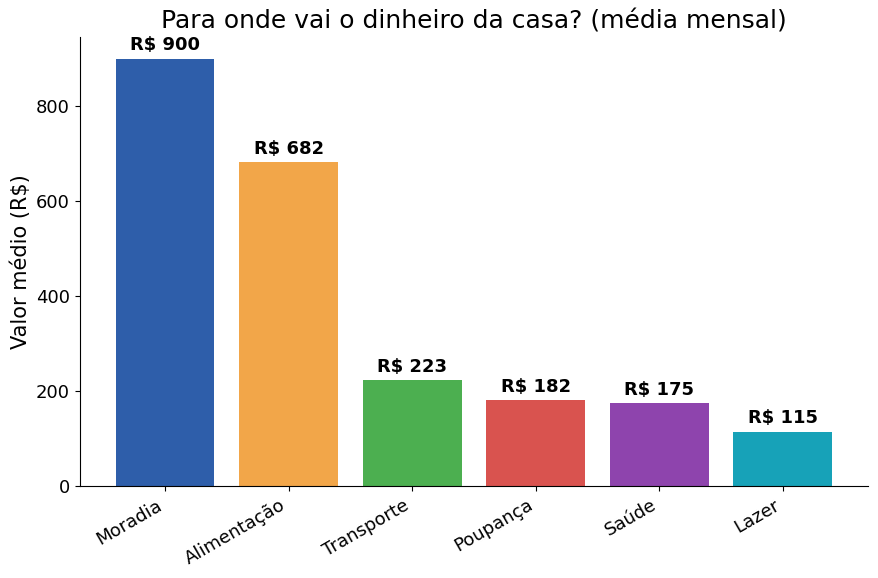

In [ ]:
media_categoria = orcamento.groupby('categoria')['valor_reais'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
barras = ax.bar(media_categoria.index, media_categoria.values, color=CORES)
ax.set_title('Para onde vai o dinheiro da casa? (média mensal)')
ax.set_ylabel('Valor médio (R$)')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'R$ {altura:,.0f}',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=13, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('grafico_gastos_por_categoria.png', dpi=150)
plt.show()


### Exemplo 2 de 4 — Evolução mensal dos gastos

**O que este gráfico mostra:** que os gastos não são sempre iguais — eles sobem e
descem de mês para mês, dependendo da categoria.

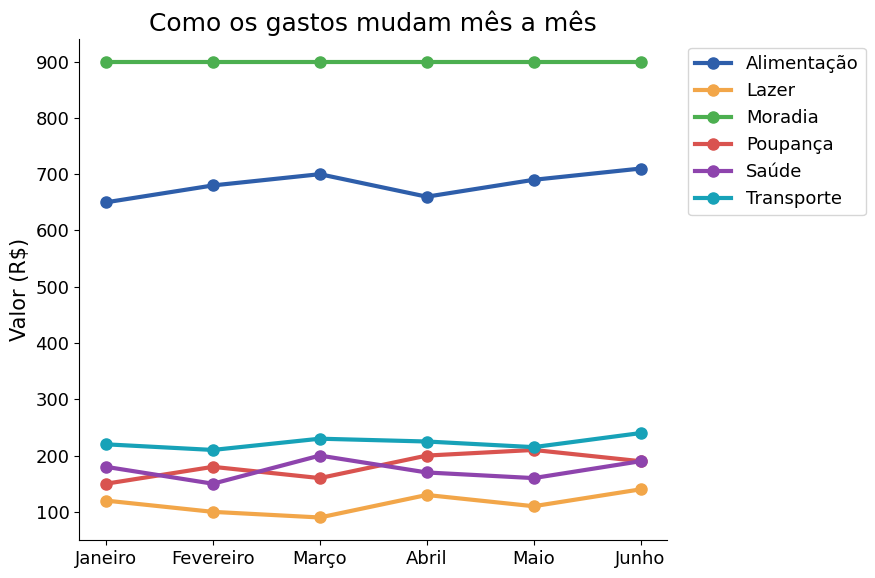

In [ ]:
pivot = orcamento.pivot(index='mes', columns='categoria', values='valor_reais')
ordem_meses = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho']
pivot = pivot.reindex(ordem_meses)

fig, ax = plt.subplots(figsize=(9, 6))
for cor, categoria in zip(CORES, pivot.columns):
    ax.plot(pivot.index, pivot[categoria], marker='o', linewidth=3,
            markersize=8, label=categoria, color=cor)

ax.set_title('Como os gastos mudam mês a mês')
ax.set_ylabel('Valor (R$)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('grafico_evolucao_gastos.png', dpi=150)
plt.show()


### Exemplo 3 de 4 — Como o orçamento se divide

**O que este gráfico mostra:** a mesma informação do Exemplo 1, mas em formato de
"fatias de pizza" — ajuda a enxergar rapidamente qual categoria ocupa a maior
parte do orçamento no total do semestre.

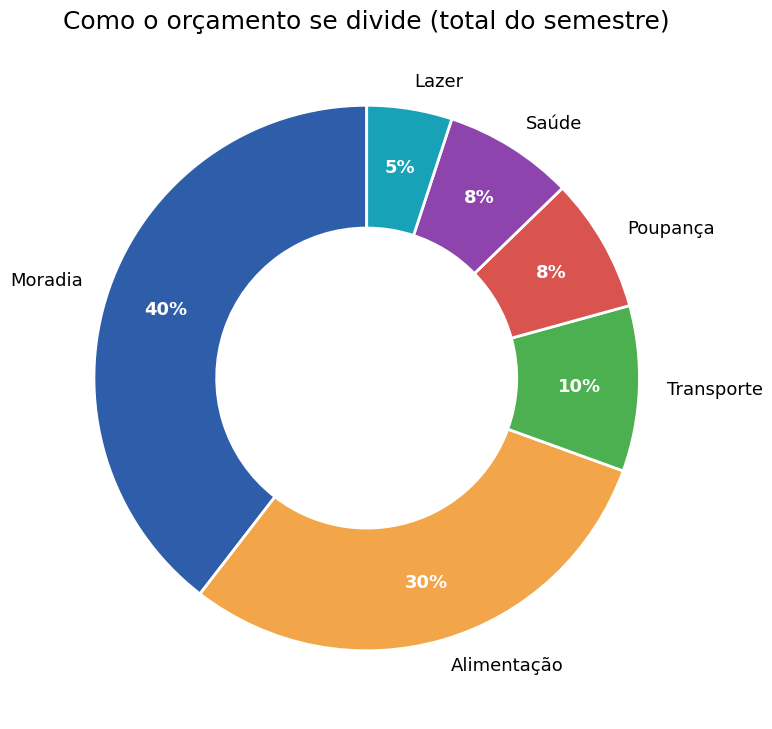

In [ ]:
total_categoria = orcamento.groupby('categoria')['valor_reais'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
wedges, textos, autotextos = ax.pie(
    total_categoria.values,
    labels=total_categoria.index,
    autopct='%1.0f%%',
    colors=CORES,
    startangle=90,
    wedgeprops={'width': 0.45, 'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.78,
    textprops={'fontsize': 13}
)
for autotexto in autotextos:
    autotexto.set_fontweight('bold')
    autotexto.set_color('white')

ax.set_title('Como o orçamento se divide (total do semestre)')
plt.tight_layout()
plt.savefig('grafico_proporcao_orcamento.png', dpi=150)
plt.show()


### Exemplo 4 de 4 — Gasto total mensal

**O que este gráfico mostra:** somando todas as categorias juntas, quanto a
família gastou no total em cada mês — útil para saber se os gastos gerais estão
aumentando ou diminuindo com o tempo.

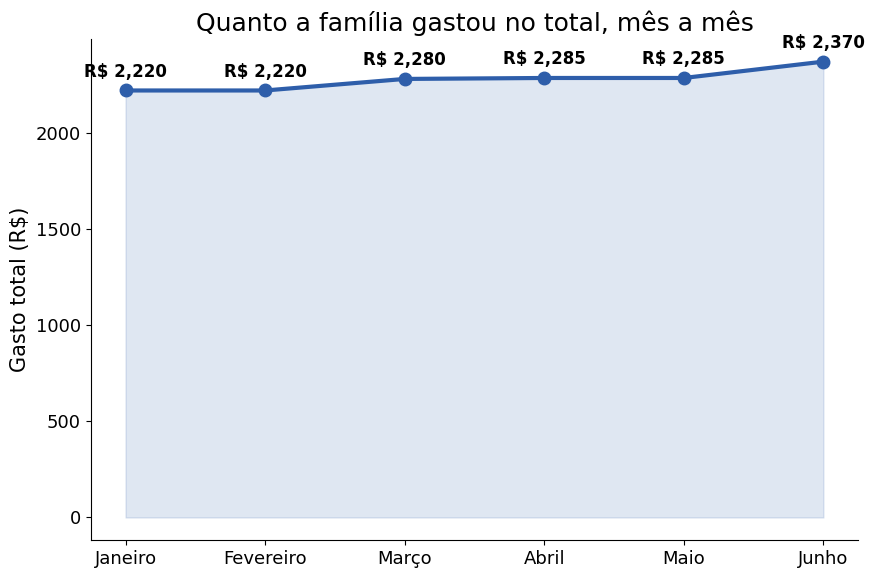

In [ ]:
gasto_total_mensal = orcamento.groupby('mes')['valor_reais'].sum().reindex(ordem_meses)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(gasto_total_mensal.index, gasto_total_mensal.values, marker='o',
        linewidth=3, markersize=9, color=CORES[0])
ax.fill_between(gasto_total_mensal.index, gasto_total_mensal.values, alpha=0.15, color=CORES[0])

for mes, valor in gasto_total_mensal.items():
    ax.annotate(f'R$ {valor:,.0f}', xy=(mes, valor), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=12, fontweight='bold')

ax.set_title('Quanto a família gastou no total, mês a mês')
ax.set_ylabel('Gasto total (R$)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('grafico_gasto_total_mensal.png', dpi=150)
plt.show()


---
## 💰 Tema 2 — Poupança

Este tema mostra **como o dinheiro guardado cresce com o tempo**, graças aos juros,
de 4 formas diferentes.

### Exemplo 1 de 4 — Crescimento da poupança com juros simples

**O que este gráfico mostra:** que guardando um pouco de dinheiro todo mês e
deixando ele render juros, o valor total cresce com o tempo — mesmo com
depósitos pequenos.

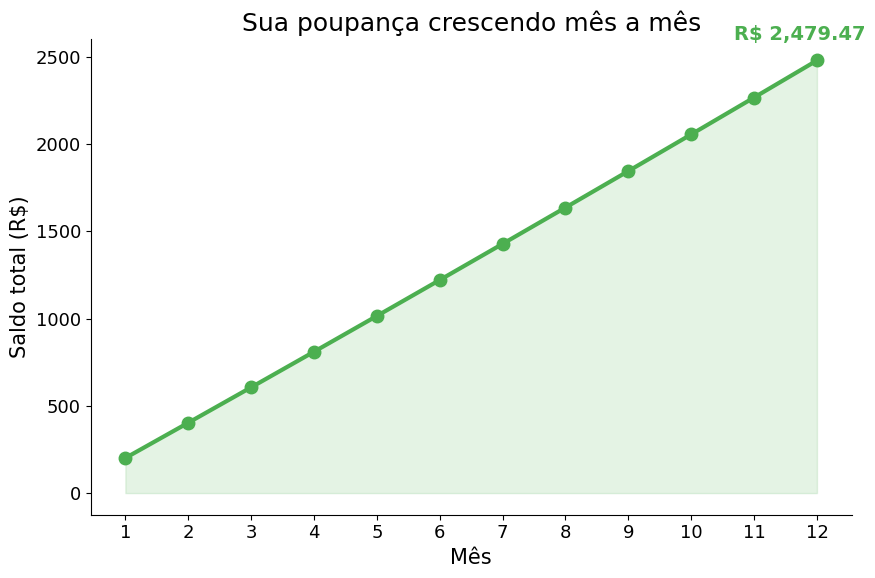

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(poupanca['mes'], poupanca['saldo_total'], marker='o',
        linewidth=3, markersize=9, color=CORES[2])
ax.fill_between(poupanca['mes'], poupanca['saldo_total'], alpha=0.15, color=CORES[2])

ax.set_title('Sua poupança crescendo mês a mês')
ax.set_xlabel('Mês')
ax.set_ylabel('Saldo total (R$)')
ax.set_xticks(poupanca['mes'])

ultimo_mes = poupanca['mes'].iloc[-1]
ultimo_saldo = poupanca['saldo_total'].iloc[-1]
ax.annotate(f'R$ {ultimo_saldo:,.2f}',
            xy=(ultimo_mes, ultimo_saldo),
            xytext=(-60, 15), textcoords='offset points',
            fontsize=14, fontweight='bold', color=CORES[2])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('grafico_poupanca_juros.png', dpi=150)
plt.show()


### Exemplo 2 de 4 — Progresso rumo a uma meta de poupança

**O que este gráfico mostra:** em qual mês a poupança atinge o valor que a pessoa
planejou economizar (a "meta"). As barras ficam verdes quando a meta é alcançada.

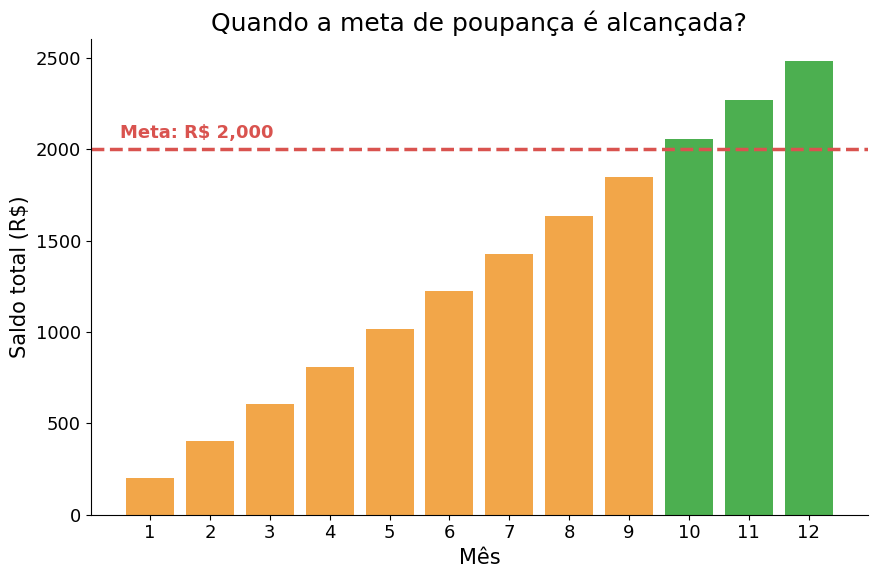

In [ ]:
META = 2000  # você pode alterar este valor para testar outras metas

fig, ax = plt.subplots(figsize=(9, 6))
cores_barras = [CORES[2] if valor >= META else CORES[1] for valor in poupanca['saldo_total']]
ax.bar(poupanca['mes'], poupanca['saldo_total'], color=cores_barras)
ax.axhline(META, color=CORES[3], linewidth=2.5, linestyle='--')
ax.text(0.5, META + 60, f'Meta: R$ {META:,.0f}', color=CORES[3], fontsize=13, fontweight='bold')

ax.set_title('Quando a meta de poupança é alcançada?')
ax.set_xlabel('Mês')
ax.set_ylabel('Saldo total (R$)')
ax.set_xticks(poupanca['mes'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('grafico_meta_poupanca.png', dpi=150)
plt.show()


### Exemplo 3 de 4 — Poupar com juros x guardar "no colchão"

**O que este gráfico mostra:** a diferença entre guardar dinheiro rendendo juros
e guardar a mesma quantia sem nenhum rendimento (como embaixo do colchão). É a
melhor forma de mostrar, visualmente, por que vale a pena usar a poupança.

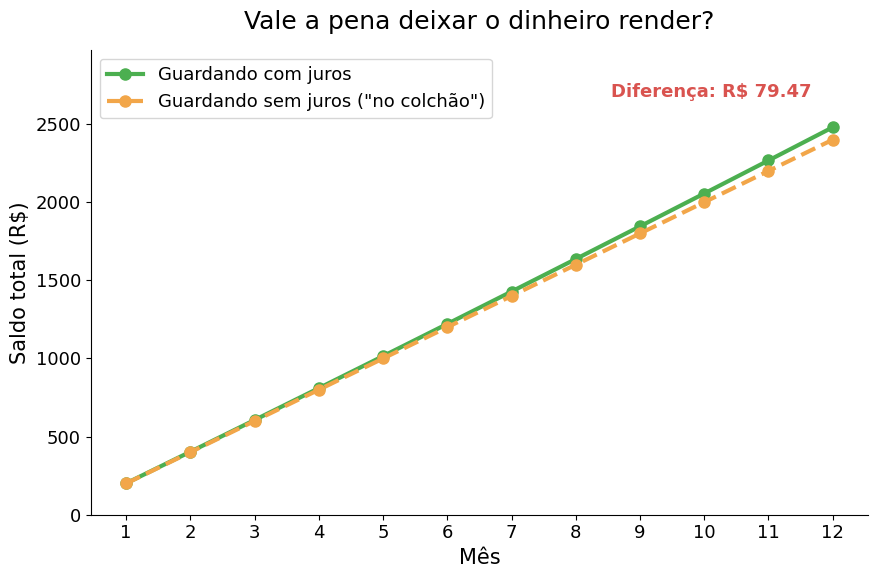

In [ ]:
# "Sem juros": soma simples do que foi depositado, mês a mês, sem nenhum rendimento
poupanca['sem_juros'] = poupanca['valor_depositado'].cumsum()

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(poupanca['mes'], poupanca['saldo_total'], marker='o', linewidth=3,
        markersize=8, label='Guardando com juros', color=CORES[2])
ax.plot(poupanca['mes'], poupanca['sem_juros'], marker='o', linewidth=3,
        markersize=8, label='Guardando sem juros ("no colchão")', color=CORES[1],
        linestyle='--')

diferenca = poupanca['saldo_total'].iloc[-1] - poupanca['sem_juros'].iloc[-1]

# Reserva um espaço acima do maior valor, para a anotação nunca colidir com o título
ax.set_ylim(0, poupanca['saldo_total'].max() * 1.2)

ax.annotate(f'Diferença: R$ {diferenca:,.2f}',
            xy=(poupanca['mes'].iloc[-1], poupanca['saldo_total'].iloc[-1]),
            xytext=(-15, 22), textcoords='offset points', ha='right',
            fontsize=13, fontweight='bold', color=CORES[3])

ax.set_title('Vale a pena deixar o dinheiro render?', pad=15)
ax.set_xlabel('Mês')
ax.set_ylabel('Saldo total (R$)')
ax.set_xticks(poupanca['mes'])
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('grafico_com_sem_juros.png', dpi=150)
plt.show()


### Exemplo 4 de 4 — Simulador interativo: e se eu guardasse outro valor?

**O que este exemplo mostra:** desta vez, é você quem decide! Mova os controles
abaixo para escolher quanto guardar por mês e a taxa de juros, e veja o gráfico
mudar na hora. É uma ótima forma de testar diferentes cenários.

In [ ]:
def simulador_poupanca(deposito_mensal=200, taxa_juros_pct=0.5):
    meses = list(range(1, 13))
    saldo = 0
    saldos = []
    for m in meses:
        juros = saldo * (taxa_juros_pct / 100)
        saldo = saldo + deposito_mensal + juros
        saldos.append(saldo)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(meses, saldos, marker='o', linewidth=3, markersize=8, color=CORES[4])
    ax.fill_between(meses, saldos, alpha=0.15, color=CORES[4])

    # Reserva um espaço acima do maior valor, para a anotação nunca colidir com o título
    ax.set_ylim(0, max(saldos) * 1.18)

    ax.annotate(f'R$ {saldos[-1]:,.2f}', xy=(meses[-1], saldos[-1]),
                xytext=(-10, 18), textcoords='offset points', ha='right',
                fontsize=14, fontweight='bold', color=CORES[4])
    ax.set_title(f'Guardando R$ {deposito_mensal}/mês a {taxa_juros_pct}% de juros ao mês', pad=15)
    ax.set_xlabel('Mês')
    ax.set_ylabel('Saldo total (R$)')
    ax.set_xticks(meses)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

# Mova os sliders abaixo para testar!
interact(
    simulador_poupanca,
    deposito_mensal=IntSlider(min=50, max=1000, step=50, value=200, description='R$/mês'),
    taxa_juros_pct=FloatSlider(min=0.1, max=2.0, step=0.1, value=0.5, description='Juros % a.m.')
);


interactive(children=(IntSlider(value=200, description='R$/mês', max=1000, min=50, step=50), FloatSlider(value…

---
## 🛡️ Tema 3 — Golpes Financeiros

Este tema ensina a **reconhecer sinais de alerta** em mensagens ou ligações
suspeitas, de 4 formas diferentes.

⚠️ Os dados usados aqui são **simulados**, criados apenas para fins didáticos —
não são estatísticas reais.

### Exemplo 1 de 4 — Pontuação de risco por situação

**O que este gráfico mostra:** quanto mais sinais de alerta uma situação tem
(contato desconhecido, pedido de senha, urgência, promessa de prêmio, pedido de
PIX), maior a chance de ser um golpe. É a mesma lógica que sistemas simples de IA
usam para decidir: observar sinais e somar o risco.

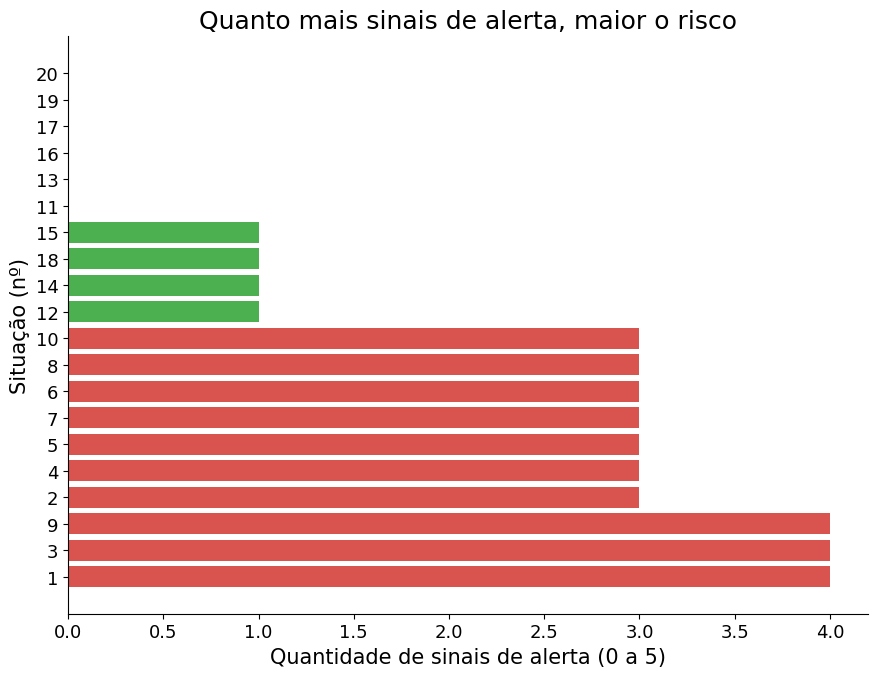

🔴 Vermelho = situação real era golpe    🟢 Verde = situação real era legítima


In [ ]:
sinais = ['contato_desconhecido', 'pede_senha_ou_codigo', 'pede_urgencia',
          'promete_premio', 'pede_pix_ou_transferencia']

# Transforma "sim"/"não" em 1/0 e soma os sinais de alerta de cada situação
golpes_score = golpes.copy()
for coluna in sinais:
    golpes_score[coluna] = (golpes_score[coluna] == 'sim').astype(int)
golpes_score['pontuacao_risco'] = golpes_score[sinais].sum(axis=1)
golpes_score = golpes_score.sort_values('pontuacao_risco', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
cores_pontos = [CORES[3] if r == 'golpe' else CORES[2] for r in golpes_score['rotulo']]
ax.barh(golpes_score['id'].astype(str), golpes_score['pontuacao_risco'], color=cores_pontos)

ax.set_title('Quanto mais sinais de alerta, maior o risco')
ax.set_xlabel('Quantidade de sinais de alerta (0 a 5)')
ax.set_ylabel('Situação (nº)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('grafico_pontuacao_risco.png', dpi=150)
plt.show()

print('🔴 Vermelho = situação real era golpe    🟢 Verde = situação real era legítima')


### Exemplo 2 de 4 — Simulador interativo: leia a mensagem e descubra o risco

**O que este exemplo mostra:** escolha uma situação no menu abaixo e veja a
mensagem que a pessoa recebeu (como um WhatsApp ou SMS de verdade), quais sinais
de alerta ela contém, qual o nível de risco e uma dica de segurança para aquele
tipo de abordagem. É uma forma de treinar o olho para reconhecer o "jeitão" de
cada golpe no dia a dia — não só olhando números, mas lendo a mensagem de verdade.

In [ ]:
nomes_sinais_simples = {
    'contato_desconhecido': '📵 Contato desconhecido',
    'pede_senha_ou_codigo': '🔑 Pede senha ou código',
    'pede_urgencia': '⏰ Pede urgência',
    'promete_premio': '🎁 Promete prêmio',
    'pede_pix_ou_transferencia': '💸 Pede PIX/transferência',
}

# Monta a lista de opções do menu: cada situação aparece com um nome fácil de entender
opcoes_situacao = [
    (f"#{row.id} — {row.tipo_golpe if row.rotulo == 'golpe' else 'Mensagem do dia a dia'}", row.id)
    for row in golpes.itertuples()
]

def simulador_mensagens(situacao_id=1):
    linha = golpes[golpes['id'] == situacao_id].iloc[0]

    print("💬 Mensagem recebida:\n")
    print(f'   "{linha.mensagem_exemplo}"\n')

    sinais_encontrados = [nomes_sinais_simples[s] for s in sinais if linha[s] == 'sim']
    pontuacao = len(sinais_encontrados)

    print(f"🔎 Sinais de alerta encontrados ({pontuacao} de 5):")
    if sinais_encontrados:
        for s in sinais_encontrados:
            print(f"   • {s}")
    else:
        print("   • Nenhum sinal de alerta encontrado")

    if pontuacao <= 1:
        veredito = "🟢 BAIXO RISCO — parece uma mensagem legítima."
    elif pontuacao <= 3:
        veredito = "🟡 RISCO MODERADO — tenha cautela, confirme por outro canal."
    else:
        veredito = "🔴 ALTO RISCO — muito provavelmente é um golpe!"

    print(f"\n{veredito}")
    print(f"\n💡 Dica: {linha.dica_seguranca}")

# Escolha uma situação no menu abaixo para testar!
interact(
    simulador_mensagens,
    situacao_id=Dropdown(options=opcoes_situacao, description='Situação:',
                          style={'description_width': 'initial'})
);


interactive(children=(Dropdown(description='Situação:', options=(('#1 — Falso Funcionário do Banco', 1), ('#2 …

### Exemplo 3 de 4 — Checklist interativo: é golpe ou não?

**O que este exemplo mostra:** agora é sua vez de avaliar! Marque as caixinhas
abaixo com os sinais de alerta que uma mensagem suspeita tem, e receba na hora
um "veredito" sobre o nível de risco — igual a um quiz.

In [ ]:
def checklist_golpe(contato_desconhecido=False, pede_senha=False, pede_urgencia=False,
                     promete_premio=False, pede_pix=False):
    sinais_marcados = [contato_desconhecido, pede_senha, pede_urgencia, promete_premio, pede_pix]
    pontuacao = sum(sinais_marcados)

    if pontuacao <= 1:
        veredito = "🟢 BAIXO RISCO — provavelmente é uma situação legítima."
    elif pontuacao <= 3:
        veredito = "🟡 RISCO MODERADO — tenha cautela e confirme por outro canal antes de agir."
    else:
        veredito = "🔴 ALTO RISCO — muito provavelmente é um golpe! Não passe senhas nem faça PIX."

    print(f"Sinais de alerta marcados: {pontuacao} de 5")
    print(veredito)

# Marque as caixinhas para testar diferentes situações!
interact(
    checklist_golpe,
    contato_desconhecido=Checkbox(value=False, description='Contato desconhecido'),
    pede_senha=Checkbox(value=False, description='Pede senha ou código'),
    pede_urgencia=Checkbox(value=False, description='Pede urgência'),
    promete_premio=Checkbox(value=False, description='Promete prêmio'),
    pede_pix=Checkbox(value=False, description='Pede PIX/transferência'),
);


interactive(children=(Checkbox(value=False, description='Contato desconhecido'), Checkbox(value=False, descrip…

### Exemplo 4 de 4 — Golpes x situações legítimas: comparando os sinais

**O que este gráfico mostra:** para cada sinal de alerta, qual a chance dele
aparecer numa situação de golpe comparado a uma situação legítima. Sinais em que
a diferença é bem grande são os mais "reveladores" de um golpe.

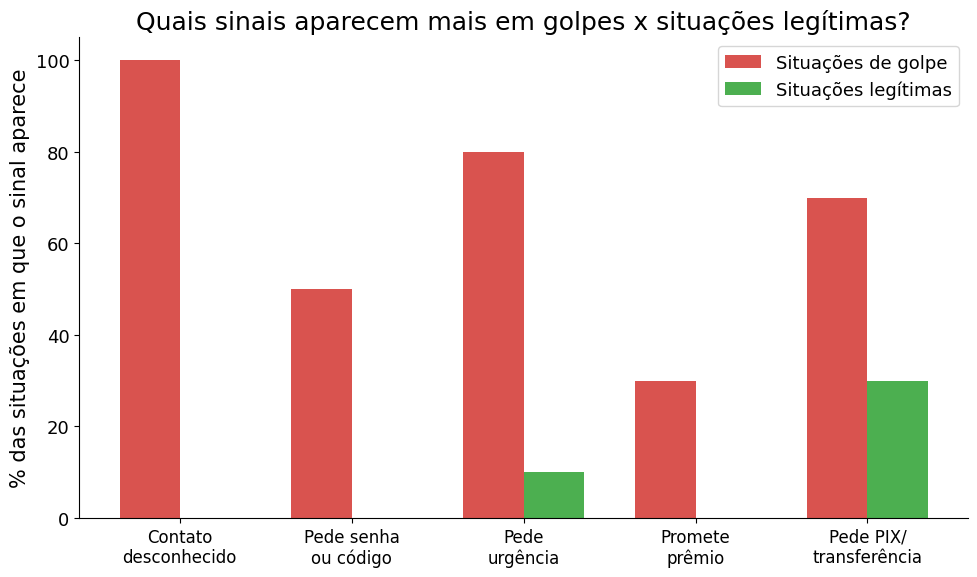

In [ ]:
golpes_only = golpes[golpes['rotulo'] == 'golpe']
legitimo_only = golpes[golpes['rotulo'] == 'legítimo']

nomes_sinais = ['Contato\ndesconhecido', 'Pede senha\nou código', 'Pede\nurgência',
                'Promete\nprêmio', 'Pede PIX/\ntransferência']
pct_golpe = [(golpes_only[s] == 'sim').mean() * 100 for s in sinais]
pct_legitimo = [(legitimo_only[s] == 'sim').mean() * 100 for s in sinais]

import numpy as np
x = np.arange(len(sinais))
largura = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - largura/2, pct_golpe, largura, label='Situações de golpe', color=CORES[3])
ax.bar(x + largura/2, pct_legitimo, largura, label='Situações legítimas', color=CORES[2])

ax.set_title('Quais sinais aparecem mais em golpes x situações legítimas?')
ax.set_ylabel('% das situações em que o sinal aparece')
ax.set_xticks(x)
ax.set_xticklabels(nomes_sinais, fontsize=12)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('grafico_comparacao_sinais.png', dpi=150)
plt.show()
